# Conception du réseau de neurones LeNet-5

#### Chargement des bibliothèques importantes


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Définition des fonctions

### Couche de convolution.

In [20]:


class Conv2D:
    """
    Couche de convolution.

    Paramètres
    ----------
    in_channels  : canaux de l'image en entrée
    out_channels : nombre de filtres
    kernel_size  : côté du filtre carré

    Attributs appris
    ----------------
    W : poids
    b : biais
    """

    # ──────────────────────────────────────────────────────────────
    # INITIALISATION
    # ──────────────────────────────────────────────────────────────
    def __init__(self, in_channels, out_channels, kernel_size):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size


        fan_in  = in_channels  * kernel_size * kernel_size   # connexions entrantes
        fan_out = out_channels * kernel_size * kernel_size   # connexions sortantes
        std = np.sqrt(2.0 / (fan_in + fan_out))

        # Poids : un filtre (in_ch × k × k) par out_channel
        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * std
        # Biais : un scalaire par filtre
        self.b = np.zeros(out_channels)

        # Gradients, remplis pendant backward
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    # ──────────────────────────────────────────────────────────────
    # FORWARD  — fait glisser chaque filtre sur l'image
    #
    #  entrée  x   : (batch, in_ch, H,     W    )
    #  sortie out  : (batch, out_ch, H_out, W_out)
    #  avec H_out  = H - k + 1
    # ──────────────────────────────────────────────────────────────
    def forward(self, x):

        self.x = x   # sauvegarde nécessaire pour le backward

        batch, in_c, H, W = x.shape
        k     = self.kernel_size
        H_out = H - k + 1
        W_out = W - k + 1

        out = np.zeros((batch, self.out_channels, H_out, W_out))

        # Pour chaque filtre f, on parcourt toutes les positions (i, j)
        for f in range(self.out_channels):
            for i in range(H_out):
                for j in range(W_out):

                    # Fenêtre courante de l'image: shape (batch, in_c, k, k)
                    region = x[:, :, i:i+k, j:j+k]

                    # Produit élément par élément
                    # résultat : un scalaire par image du batch
                    out[:, f, i, j] = np.sum(region * self.W[f], axis=(1,2,3)) + self.b[f]

        return out

    # ──────────────────────────────────────────────────────────────
    # BACKWARD — remonte le gradient et calcule les corrections
    # ──────────────────────────────────────────────────────────────
    def backward(self, d_out):

        x = self.x
        batch, in_c, H, W = x.shape
        k     = self.kernel_size
        H_out = d_out.shape[2]
        W_out = d_out.shape[3]

        # Remise à zéro des gradients avant accumulation
        dx       = np.zeros_like(x)
        self.dW  = np.zeros_like(self.W)
        self.db  = np.zeros_like(self.b)

        for f in range(self.out_channels):
            for i in range(H_out):
                for j in range(W_out):

                    region = x[:, :, i:i+k, j:j+k]  # même fenêtre que forward

                    # dL/dW — le filtre doit changer d'autant que
                    # l'entrée était forte ET l'erreur grande
                    self.dW[f] += np.sum(
                        region * d_out[:, f, i, j][:, None, None, None],
                        axis=0
                    )

                    # dL/db — biais ajouté partout → correction = somme des erreurs
                    self.db[f] += np.sum(d_out[:, f, i, j])

                    # dL/dx: chaque pixel a pu être couvert par le filtre
                    # à plusieurs positions, on accumule toutes ses responsabilités
                    dx[:, :, i:i+k, j:j+k] += (
                        self.W[f] * d_out[:, f, i, j][:, None, None, None]
                    )

        return dx

### Average Pooling

In [21]:
class AvgPool2D:
    """
    Average Pooling 2x2 avec stride=2.
    Divise les dimensions H et W par 2.
    """
    def __init__(self, pool_size=2):
        self.pool_size = pool_size

    def forward(self, x):
        """
        x shape   : (batch, channels, H, W)
        out shape : (batch, channels, H//2, W//2)
        """
        self.x = x
        batch, c, H, W = x.shape
        p = self.pool_size
        H_out = H // p
        W_out = W // p

        out = np.zeros((batch, c, H_out, W_out))
        for i in range(H_out):
            for j in range(W_out):
                # Moyenne sur la fenêtre 2x2
                out[:, :, i, j] = np.mean(
                    x[:, :, i*p:(i+1)*p, j*p:(j+1)*p],
                    axis=(2, 3)
                )
        return out

    def backward(self, d_out):
        """
        Le gradient se redistribue équitablement sur les 4 cases de la fenêtre.
        """
        x = self.x
        batch, c, H, W = x.shape
        p = self.pool_size
        H_out = d_out.shape[2]
        W_out = d_out.shape[3]

        dx = np.zeros_like(x)
        for i in range(H_out):
            for j in range(W_out):
                # Chaque case reçoit 1/4 du gradient
                dx[:, :, i*p:(i+1)*p, j*p:(j+1)*p] = (
                    d_out[:, :, i, j][:, :, None, None] / (p * p)
                )
        return dx

### Activation

In [22]:
class Tanh:
    """
    Activation Tanh : f(x) = (e^x - e^-x) / (e^x + e^-x)
    Dérivée         : f'(x) = 1 - tanh(x)²
    Utilisée dans le LeNet original (LeCun 1998)
    """
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out

    def backward(self, d_out):
        return d_out * (1 - self.out ** 2)


class ReLU:
    """
    Activation ReLU : f(x) = max(0, x)
    Dérivée         : 1 si x > 0, sinon 0
    Utilisée pour la version moderne de LeNet
    """
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, d_out):
        return d_out * (self.x > 0)

### Flatten + Linear : pour faire le lien entre les convolutions et les couches denses

In [23]:
class Flatten:
    """
    Transforme (batch, channels, H, W) en (batch, channels*H*W)
    """
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, d_out):
        return d_out.reshape(self.shape)


class Linear:
    """
    Couche linéaire (dense, fully connected).
     Y = X·W + b
    Paramètres:
        in_features  : taille du vecteur d'entrée
        out_features : taille du vecteur de sortie
    """
    def __init__(self, in_features, out_features):
        # Initialisation Xavier
        std = np.sqrt(2.0 / (in_features + out_features))
        self.W = np.random.randn(in_features, out_features) * std
        self.b = np.zeros(out_features)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, d_out):
        self.dW = self.x.T @ d_out
        self.db = np.sum(d_out, axis=0)
        return d_out @ self.W.T

 ### La Loss (Softmax + Cross-Entropy)

In [25]:
def softmax(x):
    """
    Softmax numériquement stable.
    On soustrait le max pour éviter les overflow.

    """
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def cross_entropy_loss(logits, y_true):
    """
    Calcule la Cross-Entropy Loss + son gradient.

    Paramètres:
        logits : scores bruts du modèle, shape (batch, 10)
        y_true : labels vrais, shape (batch,)

    Retourne:
        loss  : scalaire (moyenne sur le batch)
        d_out : gradient de la loss par rapport aux logits

    Astuce mathématique : la combinaison Softmax + Cross-Entropy
    donne un gradient très simple = (proba_prédite - one_hot_vrai)
    """
    batch = logits.shape[0]
    probs = softmax(logits)

    # On récupère la proba de la vraie classe pour chaque exemple
    correct_probs = probs[np.arange(batch), y_true]

    # Loss = -log(proba de la bonne classe), moyennée sur le batch
    loss = -np.mean(np.log(correct_probs + 1e-9))     # 1e-9 évite log(0)

    # Gradient = proba - 1 pour la vraie classe, proba sinon
    d_out = probs.copy()
    d_out[np.arange(batch), y_true] -= 1
    d_out /= batch                   # on divise par batch (cohérent avec mean)

    return loss, d_out

### L'Optimizer (SGD)

In [26]:
class SGD:
    """
    Stochastic Gradient Descent avec learning rate fixe.

    Règle de mise à jour : W = W - lr * dW
    """
    def __init__(self, params, lr=0.01):
        self.params = params   # liste des couches avec poids
        self.lr = lr

    def step(self):
        for layer in self.params:
            layer.W -= self.lr * layer.dW
            layer.b -= self.lr * layer.db

### Fonction d'accuracy

In [27]:
def accuracy(logits, y_true):
    """
    Calcule le pourcentage de bonnes prédictions.
    La prédiction = classe avec le score le plus élevé.
    """
    preds = np.argmax(logits, axis=1)   # indice du max sur les 10 classes
    return np.mean(preds == y_true)

# Le modèle LeNet-5

### Modèle LeNet-5

In [24]:
class LeNet5:
    """
    Architecture LeNet-5 (LeCun, 1998).

    Input  : (batch, 1, 32, 32)
    Output : (batch, 10) :  scores pour chaque chiffre 0-9

    Architecture :
        C1  : Conv(1,6,  5x5) + Tanh
        S2  : AvgPool(2x2)
        C3  : Conv(6,16, 5x5) + Tanh
        S4  : AvgPool(2x2)
        C5  : Conv(16,120, 5x5) + Tanh
        F6  : Linear(120,84) + Tanh
        Out : Linear(84,10)
    """
    def __init__(self):
        # --- Couches convolutives ---
        self.C1  = Conv2D(in_channels=1,   out_channels=6,   kernel_size=5)
        self.A1  = Tanh()

        self.S2  = AvgPool2D(pool_size=2)

        self.C3  = Conv2D(in_channels=6,   out_channels=16,  kernel_size=5)
        self.A3  = Tanh()

        self.S4  = AvgPool2D(pool_size=2)

        self.C5  = Conv2D(in_channels=16,  out_channels=120, kernel_size=5)
        self.A5  = Tanh()

        # --- Flatten ---
        self.F   = Flatten()

        # --- Couches fully connected ---
        self.F6  = Linear(in_features=120, out_features=84)
        self.A6  = Tanh()

        self.Out = Linear(in_features=84,  out_features=10)

        # Liste de toutes les couches (utile pour l'optimizer)
        self.layers = [
            self.C1, self.A1,
            self.S2,
            self.C3, self.A3,
            self.S4,
            self.C5, self.A5,
            self.F,
            self.F6, self.A6,
            self.Out
        ]

    def forward(self, x):
        """
        Passe avant : x traverse toutes les couches dans l'ordre.
        """
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out   # shape : (batch, 10) — scores bruts (logits)

    def backward(self, d_out):
        """
        Passe arrière : le gradient remonte dans l'ordre inverse.
        """
        grad = d_out
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def get_params(self):
        """
        Retourne toutes les couches qui ont des poids W et b.
        Utilisé par l'optimizer pour mettre à jour les poids.
        """
        return [l for l in self.layers if hasattr(l, 'W')]

### La Fonction d'entraînement

In [45]:
def train(model, optimizer, X_train, y_train, X_test, y_test,
          epochs=10, batch_size=32):
    """
    Boucle d'entraînement complète.

    À chaque epoch :
        1. On mélange les données
        2. On découpe en mini-batches
        3. Forward → Loss → Backward → Update
        4. On évalue sur le test set
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss' : [], 'test_acc' : []
    }

    n = X_train.shape[0]

    for epoch in range(epochs):
        # --- Mélange aléatoire à chaque epoch ---
        idx = np.random.permutation(n)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        epoch_loss = 0
        epoch_acc  = 0
        n_batches  = 0

        # --- Mini-batches ---
        for start in range(0, n, batch_size):
            xb = X_shuffled[start : start + batch_size]
            yb = y_shuffled[start : start + batch_size]

            # 1. Forward pass
            logits = model.forward(xb)

            # 2. Loss + gradient
            loss, d_out = cross_entropy_loss(logits, yb)

            # 3. Backward pass
            model.backward(d_out)

            # 4. Mise à jour des poids
            optimizer.step()

            # 5. Métriques du batch
            epoch_loss += loss
            epoch_acc  += accuracy(logits, yb)
            n_batches  += 1

        # --- Moyenne sur tous les batches ---
        epoch_loss /= n_batches
        epoch_acc  /= n_batches

        # --- Évaluation sur le test set ---
        # On évalue par petits blocs pour ne pas saturer la RAM
        test_loss, test_acc = evaluate(model, X_test, y_test, batch_size=128)

        # --- Sauvegarde de l'historique ---
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}  | Test Acc: {test_acc:.4f}")

    return history

### Fonction d'évaluation

In [46]:
def evaluate(model, X, y, batch_size=128):
    """
    Évalue le modèle sur un dataset complet.
    On ne fait PAS de backward ici (pas d'apprentissage).
    """
    total_loss = 0
    total_acc  = 0
    n_batches  = 0

    for start in range(0, X.shape[0], batch_size):
        xb = X[start : start + batch_size]
        yb = y[start : start + batch_size]

        logits = model.forward(xb)
        loss, _ = cross_entropy_loss(logits, yb)

        total_loss += loss
        total_acc  += accuracy(logits, yb)
        n_batches  += 1

    return total_loss / n_batches, total_acc / n_batches

# Test du modèle complet

## Préparation des données

#### Chargement de MNIST

In [51]:
# Chargement du dataset MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

# Vérification de la taille des données
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes : {np.unique(y)}")

X shape: (70000, 784)
y shape: (70000,)
Classes : [0 1 2 3 4 5 6 7 8 9]


#### Formatage des données

In [52]:
# 1. Normalisation : pixels entre 0 et 1
X = X / 255.0

#    Format attendu par nos convolutions : (batch, channels, hauteur, largeur)
X = X.reshape(-1, 1, 28, 28)


#    On ajoute 2 pixels de zéros tout autour
X = np.pad(X, ((0,0), (0,0), (2,2), (2,2)), mode='constant')

print(f"X après reshape + padding : {X.shape}")

# 4. Split : 60000 train / 10000 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

X après reshape + padding : (70000, 1, 32, 32)
Train : (60000, 1, 32, 32), Test : (10000, 1, 32, 32)


#### Visualisation de quelques données

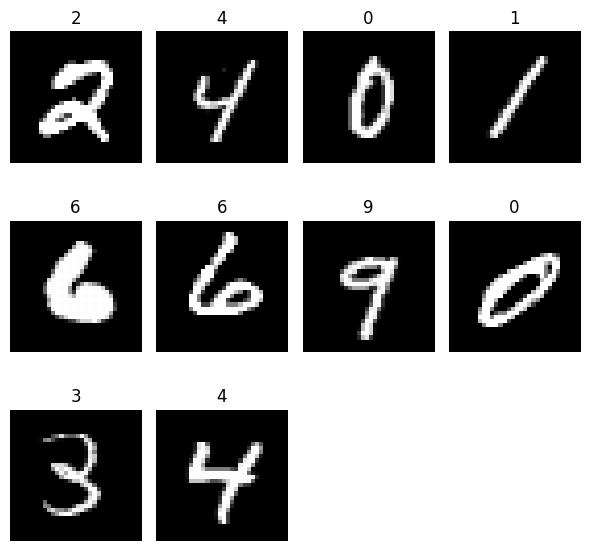

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for i in range(10):
    plt.subplot(3, 4, i+1)   # 2 lignes, 2 colonnes
    plt.imshow(X_train[i, 0], cmap="gray")
    plt.title(f"{y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Entraînement du modèle

#### Stockage de l'historique de l'entraînement

In [59]:
N_TRAIN = 2000
N_TEST  = 500

X_tr = X_train[:N_TRAIN]
y_tr = y_train[:N_TRAIN]
X_te = X_test[:N_TEST]
y_te = y_test[:N_TEST]

# Instancier modèle + optimizer
model     = LeNet5()
optimizer = SGD(model.get_params(), lr=0.01)

print("🚀 Début de l'entraînement...\n")

history = train(
    model, optimizer,
    X_tr, y_tr,
    X_te, y_te,
    epochs=10,
    batch_size=32
)

🚀 Début de l'entraînement...

Epoch 01/10 | Train Loss: 2.2448 | Train Acc: 0.2946 | Test Loss: 2.1612  | Test Acc: 0.5546
Epoch 02/10 | Train Loss: 2.0251 | Train Acc: 0.6220 | Test Loss: 1.8340  | Test Acc: 0.6271
Epoch 03/10 | Train Loss: 1.5841 | Train Acc: 0.6984 | Test Loss: 1.3308  | Test Acc: 0.7008
Epoch 04/10 | Train Loss: 1.1230 | Train Acc: 0.7560 | Test Loss: 0.9843  | Test Acc: 0.7549
Epoch 05/10 | Train Loss: 0.8553 | Train Acc: 0.8070 | Test Loss: 0.8043  | Test Acc: 0.8028
Epoch 06/10 | Train Loss: 0.7115 | Train Acc: 0.8309 | Test Loss: 0.7026  | Test Acc: 0.8225
Epoch 07/10 | Train Loss: 0.6229 | Train Acc: 0.8517 | Test Loss: 0.6313  | Test Acc: 0.8401
Epoch 08/10 | Train Loss: 0.5653 | Train Acc: 0.8621 | Test Loss: 0.5852  | Test Acc: 0.8423
Epoch 09/10 | Train Loss: 0.5241 | Train Acc: 0.8700 | Test Loss: 0.5410  | Test Acc: 0.8522
Epoch 10/10 | Train Loss: 0.4836 | Train Acc: 0.8800 | Test Loss: 0.5074  | Test Acc: 0.8640


#### Visualisation des courbes

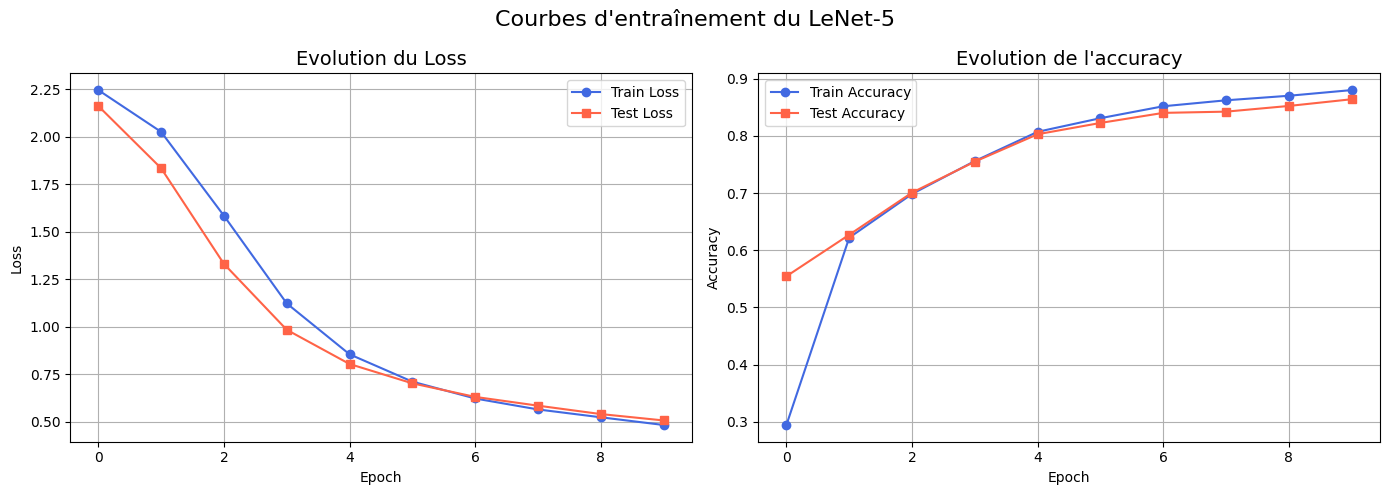


 Accuracy finale sur le test : 86.40%


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Courbe de Loss ---
axes[0].plot(history['train_loss'], label='Train Loss', color='royalblue', marker='o')
axes[0].plot(history['test_loss'],  label='Test Loss',  color='tomato',    marker='s')
axes[0].set_title('Evolution du Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Courbe d'Accuracy ---
axes[1].plot(history['train_acc'], label='Train Accuracy', color='royalblue', marker='o')
axes[1].plot(history['test_acc'],  label='Test Accuracy',  color='tomato',    marker='s')
axes[1].set_title('Evolution de l\'accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Courbes d\'entraînement du LeNet-5', fontsize=16)
plt.tight_layout()
plt.savefig('lenet5_training_curves.png', dpi=150)
plt.show()

print(f"\n Accuracy finale sur le test : {history['test_acc'][-1]*100:.2f}%")

#### Batch Normalization

In [61]:
class BatchNorm:
    """
    Batch Normalization (Ioffe & Szegedy, 2015).

    Fonctionne sur des features 1D : shape (batch, features)

    Paramètres appris :
        gamma : facteur d'échelle (initialisé à 1)
        beta  : décalage          (initialisé à 0)

    Hyperparamètre :
        momentum : pour la moyenne mobile (inférence)
        eps      : stabilité numérique
    """
    def __init__(self, num_features, momentum=0.9, eps=1e-5):
        self.gamma = np.ones(num_features)   # scale
        self.beta  = np.zeros(num_features)  # shift
        self.eps   = eps
        self.momentum = momentum

        # Gradients
        self.dgamma = np.zeros_like(self.gamma)
        self.dbeta  = np.zeros_like(self.beta)

        # Moyennes mobiles pour l'inférence
        self.running_mean = np.zeros(num_features)
        self.running_var  = np.ones(num_features)

        # Mode : 'train' ou 'test'
        self.mode = 'train'

    def forward(self, x):
        if self.mode == 'train':
            # 1. Moyenne et variance du batch
            mu  = np.mean(x, axis=0)               # (features,)
            var = np.var(x,  axis=0)               # (features,)

            # 2. Normalisation
            self.x_norm = (x - mu) / np.sqrt(var + self.eps)

            # 3. Mise à l'échelle
            out = self.gamma * self.x_norm + self.beta

            # 4. Mise à jour des moyennes mobiles
            self.running_mean = (self.momentum * self.running_mean
                                 + (1 - self.momentum) * mu)
            self.running_var  = (self.momentum * self.running_var
                                 + (1 - self.momentum) * var)

            # Sauvegarde pour le backward
            self.mu  = mu
            self.var = var
            self.x   = x

        else:
            # En inférence : on utilise les moyennes mobiles
            x_norm = ((x - self.running_mean)
                      / np.sqrt(self.running_var + self.eps))
            out = self.gamma * x_norm + self.beta

        return out

    def backward(self, d_out):
        batch = self.x.shape[0]

        # Gradient de gamma et beta
        self.dgamma = np.sum(d_out * self.x_norm, axis=0)
        self.dbeta  = np.sum(d_out, axis=0)

        # Gradient de x_norm
        dx_norm = d_out * self.gamma

        # Gradient de x (formule complète de la backprop BN)
        std_inv = 1.0 / np.sqrt(self.var + self.eps)
        dx = (1.0 / batch) * std_inv * (
            batch * dx_norm
            - np.sum(dx_norm, axis=0)
            - self.x_norm * np.sum(dx_norm * self.x_norm, axis=0)
        )
        return dx

    # BatchNorm a aussi des paramètres W=gamma, b=beta
    # On les expose pour que l'optimizer puisse les mettre à jour
    @property
    def W(self): return self.gamma
    @W.setter
    def W(self, v): self.gamma = v

    @property
    def b(self): return self.beta
    @b.setter
    def b(self, v): self.beta = v

    @property
    def dW(self): return self.dgamma
    @dW.setter
    def dW(self, v): self.dgamma = v

    @property
    def db(self): return self.dbeta
    @db.setter
    def db(self, v): self.dbeta = v

#### LeNet-5 avec Batch Norm

In [62]:
class LeNet5WithBN:
    """
    LeNet-5 avec Batch Normalization après chaque couche Linear.

    Différence vs LeNet5 standard :
        F6 : Linear(120→84) → BatchNorm(84) → Tanh
    """
    def __init__(self):
        self.C1  = Conv2D(1,   6,   5)
        self.A1  = Tanh()
        self.S2  = AvgPool2D(2)
        self.C3  = Conv2D(6,   16,  5)
        self.A3  = Tanh()
        self.S4  = AvgPool2D(2)
        self.C5  = Conv2D(16,  120, 5)
        self.A5  = Tanh()
        self.F   = Flatten()
        self.F6  = Linear(120, 84)
        self.BN  = BatchNorm(84)
        self.A6  = Tanh()
        self.Out = Linear(84, 10)

        self.layers = [
            self.C1, self.A1,
            self.S2,
            self.C3, self.A3,
            self.S4,
            self.C5, self.A5,
            self.F,
            self.F6, self.BN, self.A6,
            self.Out
        ]

    def forward(self, x, mode='train'):
        self.BN.mode = mode
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, d_out):
        grad = d_out
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def get_params(self):
        return [l for l in self.layers if hasattr(l, 'W')]

#### Entrainement des deux modèles pour une comparaison

In [63]:

# Données d'entrainement
N_TRAIN = 2000
N_TEST  = 500
X_tr = X_train[:N_TRAIN]
y_tr = y_train[:N_TRAIN]
X_te = X_test[:N_TEST]
y_te = y_test[:N_TEST]

EPOCHS     = 10
BATCH_SIZE = 32
LR         = 0.01

# --- Modèle SANS Batch Norm ---
print("\n Entraînement SANS Batch Normalization...")
model_no_bn  = LeNet5()
optim_no_bn  = SGD(model_no_bn.get_params(), lr=LR)
history_no_bn = train(model_no_bn, optim_no_bn,
                      X_tr, y_tr, X_te, y_te,
                      epochs=EPOCHS, batch_size=BATCH_SIZE)

# --- Modèle AVEC Batch Norm ---
print("\n Entraînement AVEC Batch Normalization...")
model_bn  = LeNet5WithBN()
optim_bn  = SGD(model_bn.get_params(), lr=LR)
history_bn = train(model_bn, optim_bn,
                   X_tr, y_tr, X_te, y_te,
                   epochs=EPOCHS, batch_size=BATCH_SIZE)

   ABLATION STUDY — Batch Normalization

🔵 Entraînement SANS Batch Normalization...
Epoch 01/10 | Train Loss: 2.2133 | Train Acc: 0.3036 | Test Loss: 2.1123  | Test Acc: 0.5677
Epoch 02/10 | Train Loss: 1.9177 | Train Acc: 0.6364 | Test Loss: 1.7018  | Test Acc: 0.6089
Epoch 03/10 | Train Loss: 1.4105 | Train Acc: 0.7044 | Test Loss: 1.2259  | Test Acc: 0.7029
Epoch 04/10 | Train Loss: 1.0204 | Train Acc: 0.7604 | Test Loss: 0.9487  | Test Acc: 0.7653
Epoch 05/10 | Train Loss: 0.8094 | Train Acc: 0.8105 | Test Loss: 0.8009  | Test Acc: 0.7829
Epoch 06/10 | Train Loss: 0.6912 | Train Acc: 0.8368 | Test Loss: 0.7134  | Test Acc: 0.7952
Epoch 07/10 | Train Loss: 0.6150 | Train Acc: 0.8492 | Test Loss: 0.6467  | Test Acc: 0.8268
Epoch 08/10 | Train Loss: 0.5606 | Train Acc: 0.8641 | Test Loss: 0.6035  | Test Acc: 0.8345
Epoch 09/10 | Train Loss: 0.5195 | Train Acc: 0.8705 | Test Loss: 0.5602  | Test Acc: 0.8423
Epoch 10/10 | Train Loss: 0.4870 | Train Acc: 0.8790 | Test Loss: 0.5259  | Tes

#### Comparaison visuelle

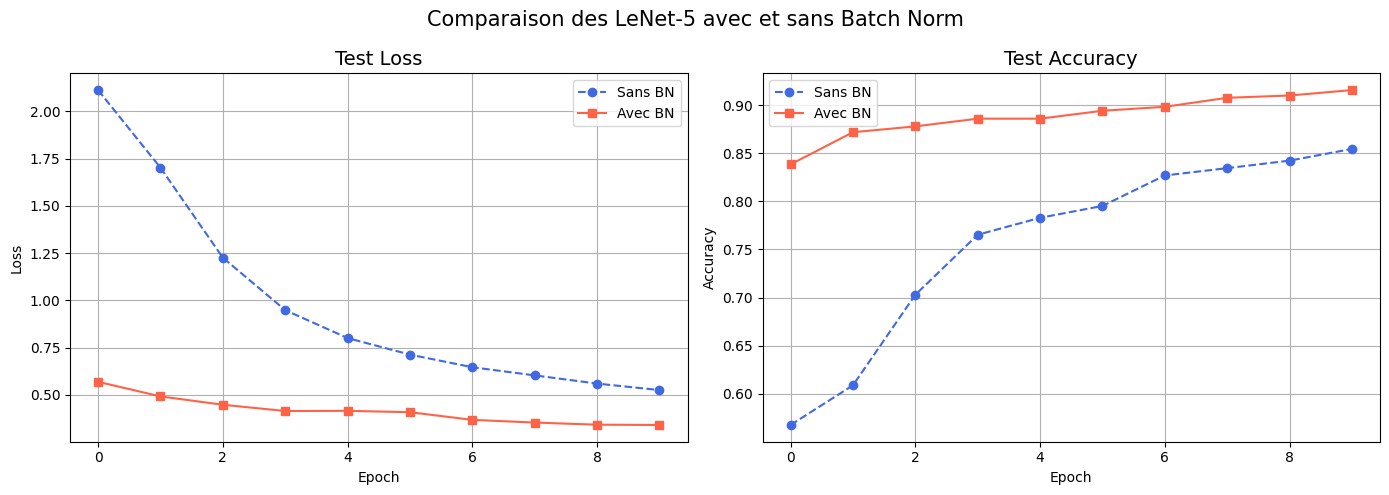


📊 Résultats finaux :
  Sans BN, Test Acc : 85.44%
  Avec BN, Test Acc : 91.55%
  Gain BN : +6.12%


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(history_no_bn['test_loss'], label='Sans BN',
             color='royalblue', marker='o', linestyle='--')
axes[0].plot(history_bn['test_loss'],    label='Avec BN',
             color='tomato',    marker='s')
axes[0].set_title('Test Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(history_no_bn['test_acc'], label='Sans BN',
             color='royalblue', marker='o', linestyle='--')
axes[1].plot(history_bn['test_acc'],    label='Avec BN',
             color='tomato',    marker='s')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Comparaison des LeNet-5 avec et sans Batch Norm',
             fontsize=15)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

# --- Résumé chiffré ---
print("\n📊 Résultats finaux :")
print(f"  Sans BN, Test Acc : {history_no_bn['test_acc'][-1]*100:.2f}%")
print(f"  Avec BN, Test Acc : {history_bn['test_acc'][-1]*100:.2f}%")
diff = (history_bn['test_acc'][-1] - history_no_bn['test_acc'][-1]) * 100
print(f"  Gain BN : {diff:+.2f}%")